In [12]:
import fiftyone as fo
import fiftyone.zoo as foz
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import seaborn as sns
from PIL import Image
from collections import Counter
from itertools import combinations
import os

In [13]:
VEHICLE_CLASSES = ["car", "bus", "truck"]
DATASET_DIR = os.path.abspath("../data/coco")
SPLIT = "validation"

fo.config.dataset_zoo_dir = DATASET_DIR

## Download COCO val2017 — vehicle classes only

In [14]:
dataset = foz.load_zoo_dataset(
    "coco-2017",
    split=SPLIT,
    label_types=["detections"],
    classes=VEHICLE_CLASSES,
    only_matching=True,
    drop_existing_dataset=True,
)

print(f"Total samples: {len(dataset)}")

Found annotations at '/Users/danylotsebro/code/diploma/data/coco/coco-2017/raw/instances_val2017.json'
Sufficient images already downloaded
Existing download of split 'validation' is sufficient
Deleting existing dataset 'coco-2017-validation'
Loading 'coco-2017' split 'validation'
 100% |█████████████████| 707/707 [649.0ms elapsed, 0s remaining, 1.1K samples/s]       
Dataset 'coco-2017-validation' created
Total samples: 707


## Class distribution

In [15]:
class_counts = Counter()
images_per_class = Counter()

for sample in dataset:
    labels_in_sample = set()
    if sample.ground_truth:
        for det in sample.ground_truth.detections:
            class_counts[det.label] += 1
            labels_in_sample.add(det.label)
    for label in labels_in_sample:
        images_per_class[label] += 1

dist_df = pd.DataFrame({
    "class": list(class_counts.keys()),
    "total_instances": list(class_counts.values()),
    "images_containing": [images_per_class[c] for c in class_counts.keys()]
}).sort_values("total_instances", ascending=False)

print(dist_df.to_string(index=False))

class  total_instances  images_containing
  car             1932                535
truck              415                250
  bus              285                189


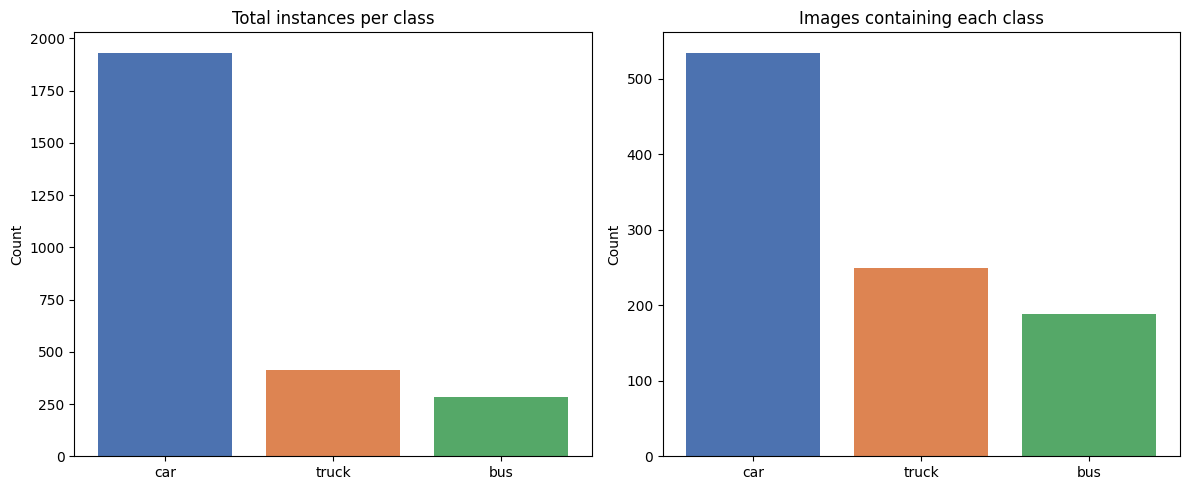

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(dist_df["class"], dist_df["total_instances"], color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Total instances per class")
axes[0].set_ylabel("Count")

axes[1].bar(dist_df["class"], dist_df["images_containing"], color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_title("Images containing each class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(DATASET_DIR, "class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

## Bounding box size distribution

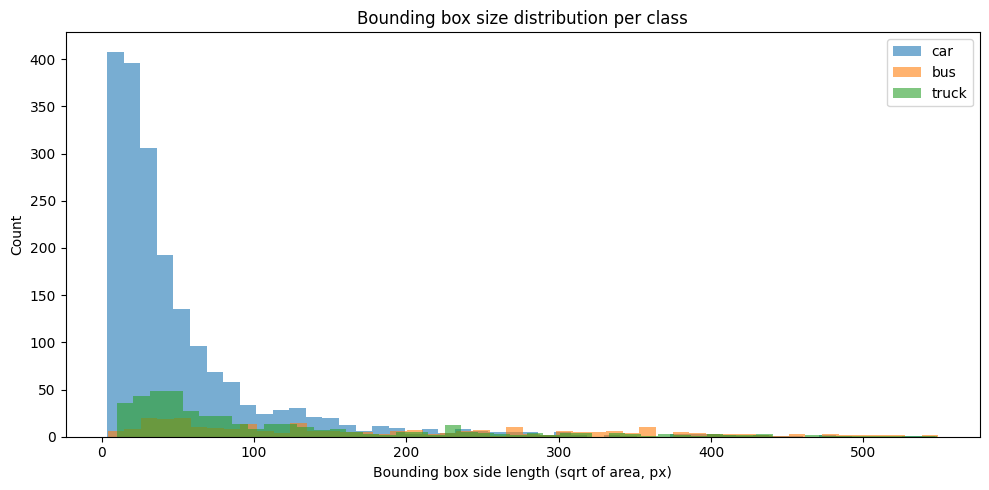

In [17]:
bbox_areas = {cls: [] for cls in VEHICLE_CLASSES}

for sample in dataset:
    if not sample.ground_truth:
        continue
    img = Image.open(sample.filepath)
    w, h = img.size
    for det in sample.ground_truth.detections:
        bw = det.bounding_box[2] * w
        bh = det.bounding_box[3] * h
        if det.label in bbox_areas:
            bbox_areas[det.label].append(bw * bh)

fig, ax = plt.subplots(figsize=(10, 5))
for cls, areas in bbox_areas.items():
    if areas:
        ax.hist(np.sqrt(areas), bins=50, alpha=0.6, label=cls)
ax.set_xlabel("Bounding box side length (sqrt of area, px)")
ax.set_ylabel("Count")
ax.set_title("Bounding box size distribution per class")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATASET_DIR, "bbox_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

## Sample images with ground truth boxes

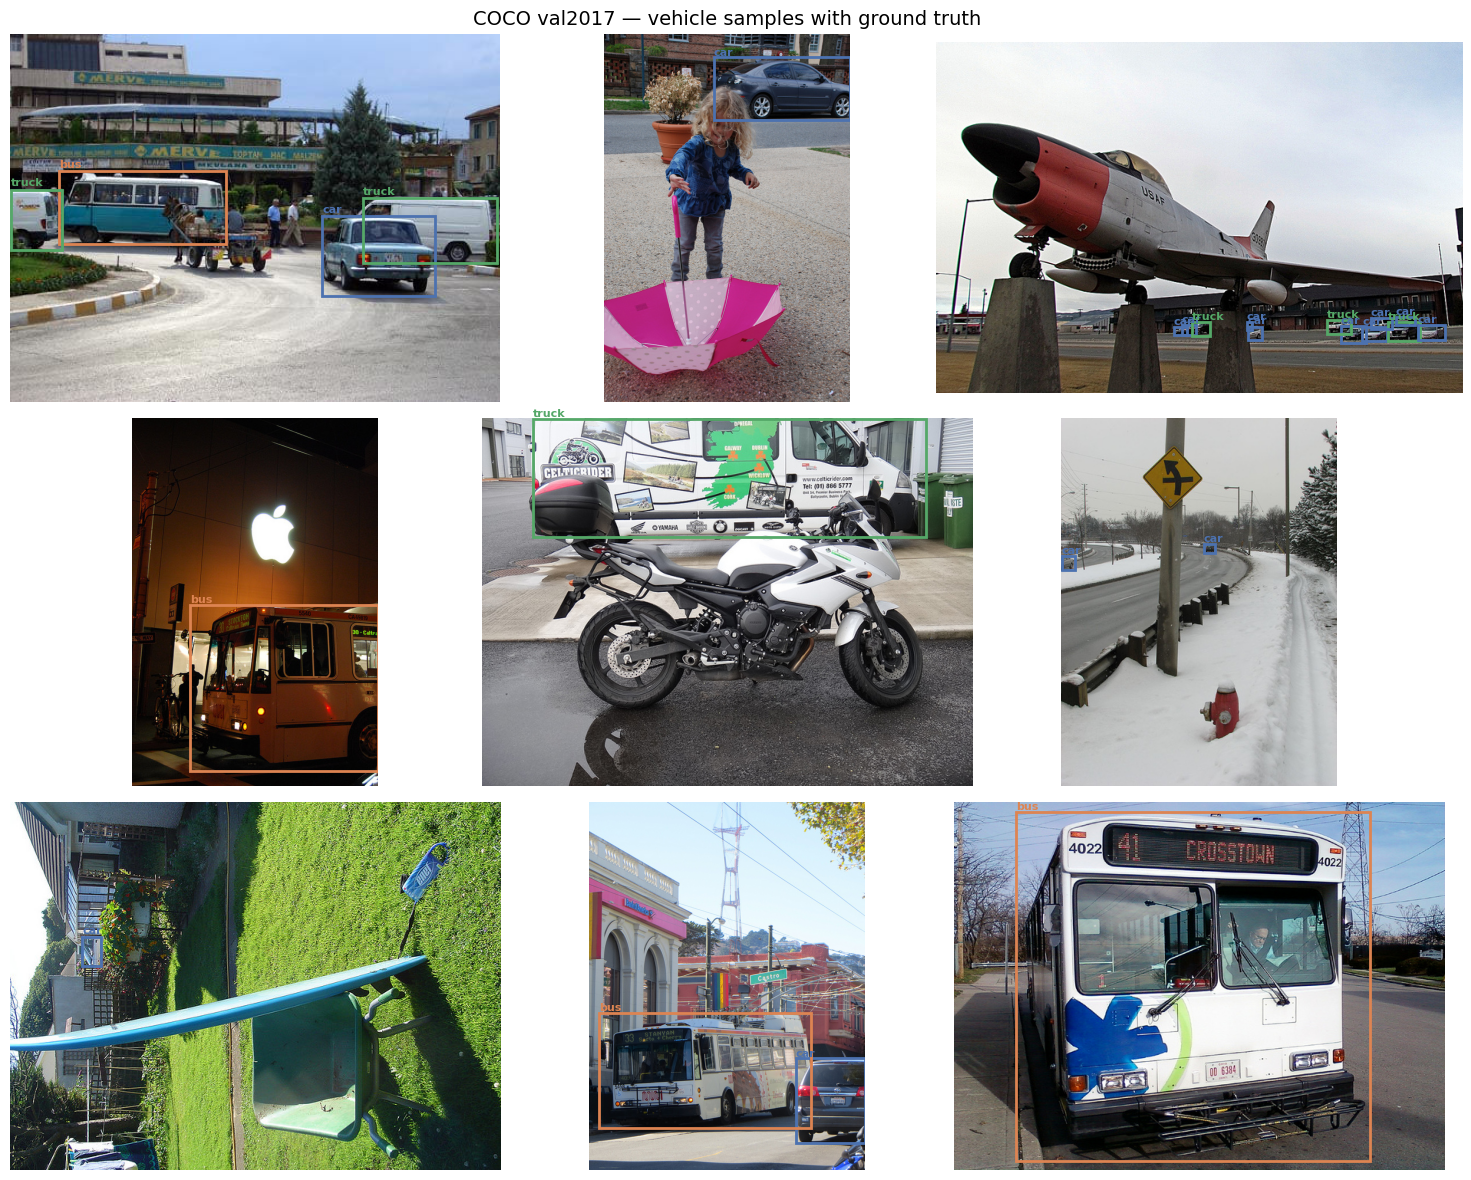

In [18]:
CLASS_COLORS = {"car": "#4C72B0", "bus": "#DD8452", "truck": "#55A868"}

samples = list(dataset.take(9))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, sample in zip(axes.flatten(), samples):
    img = Image.open(sample.filepath)
    w, h = img.size
    ax.imshow(img)
    if sample.ground_truth:
        for det in sample.ground_truth.detections:
            x, y, bw, bh = det.bounding_box
            rect = patches.Rectangle(
                (x * w, y * h), bw * w, bh * h,
                linewidth=2, edgecolor=CLASS_COLORS.get(det.label, "red"), facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x * w, y * h - 4, det.label, color=CLASS_COLORS.get(det.label, "red"),
                    fontsize=8, fontweight="bold")
    ax.axis("off")

plt.suptitle("COCO val2017 — vehicle samples with ground truth", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATASET_DIR, "sample_images.png"), dpi=150, bbox_inches="tight")
plt.show()

## Export image paths + annotations for evaluation notebooks

In [19]:
ANNOTATION_COLUMNS = ["image_id", "filepath", "label", "x1", "y1", "x2", "y2", "img_width", "img_height"]

records = []
for sample in dataset:
    if not sample.ground_truth:
        continue
    img = Image.open(sample.filepath)
    w, h = img.size
    for det in sample.ground_truth.detections:
        if det.label not in VEHICLE_CLASSES:
            continue
        x, y, bw, bh = det.bounding_box
        records.append({
            "image_id": sample.id,
            "filepath": sample.filepath,
            "label": det.label,
            "x1": x * w,
            "y1": y * h,
            "x2": (x + bw) * w,
            "y2": (y + bh) * h,
            "img_width": w,
            "img_height": h,
        })

annotations_df = pd.DataFrame(records, columns=ANNOTATION_COLUMNS)
annotations_df.to_csv(os.path.join(DATASET_DIR, "annotations.csv"), index=False)
print(f"Saved {len(annotations_df)} annotations from {annotations_df['image_id'].nunique()} images")
annotations_df.head()

Saved 2632 annotations from 707 images


,image_id,filepath,label,x1,y1,x2,y2,img_width,img_height
0,6a10b2215a6d7a1b277e83ae,/Users/danylotsebro/code/diploma/data/coco/coc...,car,171.76,203.56,207.14,222.96,640,361
1,6a10b2215a6d7a1b277e83ae,/Users/danylotsebro/code/diploma/data/coco/coc...,car,282.55,202.06,302.39,212.20,640,361
2,6a10b2215a6d7a1b277e83ae,/Users/danylotsebro/code/diploma/data/coco/coc...,car,332.46,200.85,345.05,209.91,640,361
3,6a10b2215a6d7a1b277e83ae,/Users/danylotsebro/code/diploma/data/coco/coc...,bus,361.51,194.03,389.18,224.01,640,361
4,6a10b2215a6d7a1b277e83ae,/Users/danylotsebro/code/diploma/data/coco/coc...,truck,362.11,192.66,389.52,223.23,640,361


## Objects per image & size categories

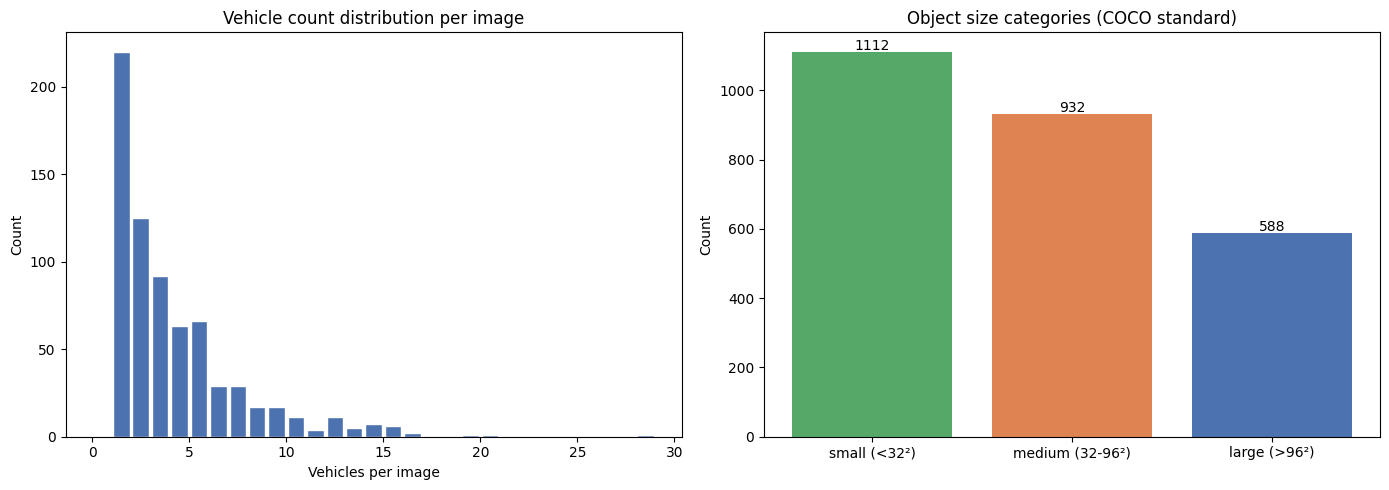

In [20]:
objects_per_image = []
size_counts = {"small (<32²)": 0, "medium (32-96²)": 0, "large (>96²)": 0}

for sample in dataset:
    if not sample.ground_truth:
        continue
    img = Image.open(sample.filepath)
    w, h = img.size
    count = 0
    for det in sample.ground_truth.detections:
        if det.label not in VEHICLE_CLASSES:
            continue
        area = (det.bounding_box[2] * w) * (det.bounding_box[3] * h)
        if area < 32 ** 2:
            size_counts["small (<32²)"] += 1
        elif area < 96 ** 2:
            size_counts["medium (32-96²)"] += 1
        else:
            size_counts["large (>96²)"] += 1
        count += 1
    objects_per_image.append(count)

if not objects_per_image:
    print("No objects found in dataset.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(objects_per_image, bins=range(0, max(objects_per_image) + 2),
                 color="#4C72B0", edgecolor="white", rwidth=0.85)
    axes[0].set_xlabel("Vehicles per image")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Vehicle count distribution per image")

    colors = ["#55A868", "#DD8452", "#4C72B0"]
    bars = axes[1].bar(size_counts.keys(), size_counts.values(), color=colors)
    axes[1].set_title("Object size categories (COCO standard)")
    axes[1].set_ylabel("Count")
    for bar, val in zip(bars, size_counts.values()):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                     str(val), ha="center", fontsize=10)

    plt.tight_layout()
    plt.savefig(os.path.join(DATASET_DIR, "objects_per_image.png"), dpi=150, bbox_inches="tight")
    plt.show()

## Bounding box shape heatmap

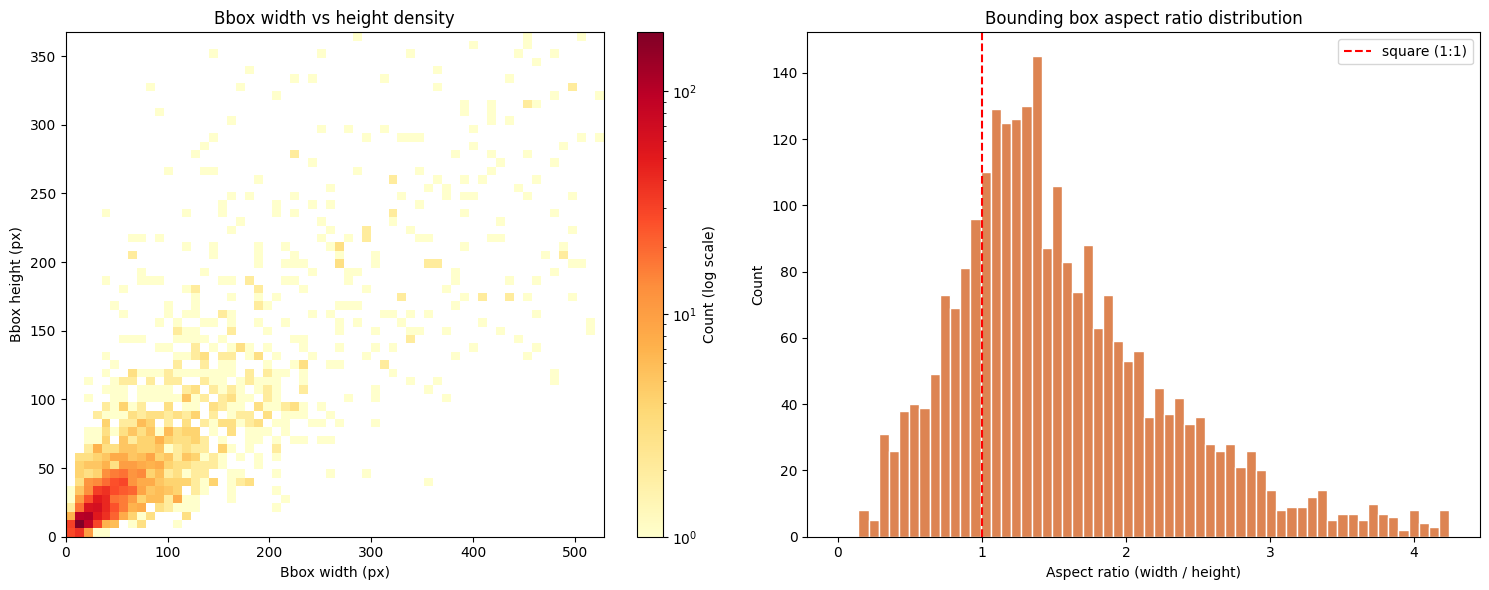

In [21]:
all_widths, all_heights = [], []

for sample in dataset:
    if not sample.ground_truth:
        continue
    img = Image.open(sample.filepath)
    w, h = img.size
    for det in sample.ground_truth.detections:
        if det.label not in VEHICLE_CLASSES:
            continue
        all_widths.append(det.bounding_box[2] * w)
        all_heights.append(det.bounding_box[3] * h)

clip_w = np.percentile(all_widths, 98)
clip_h = np.percentile(all_heights, 98)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

h2d = axes[0].hist2d(all_widths, all_heights, bins=60, cmap="YlOrRd",
                     norm=plt.matplotlib.colors.LogNorm(),
                     range=[[0, clip_w], [0, clip_h]])
plt.colorbar(h2d[3], ax=axes[0], label="Count (log scale)")
axes[0].set_xlabel("Bbox width (px)")
axes[0].set_ylabel("Bbox height (px)")
axes[0].set_title("Bbox width vs height density")

aspect_ratios = np.array(all_widths) / (np.array(all_heights) + 1e-6)
axes[1].hist(aspect_ratios, bins=60, color="#DD8452", edgecolor="white",
             range=(0, np.percentile(aspect_ratios, 98)))
axes[1].axvline(1.0, color="red", linestyle="--", label="square (1:1)")
axes[1].set_xlabel("Aspect ratio (width / height)")
axes[1].set_ylabel("Count")
axes[1].set_title("Bounding box aspect ratio distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DATASET_DIR, "bbox_shape_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

## Class co-occurrence matrix

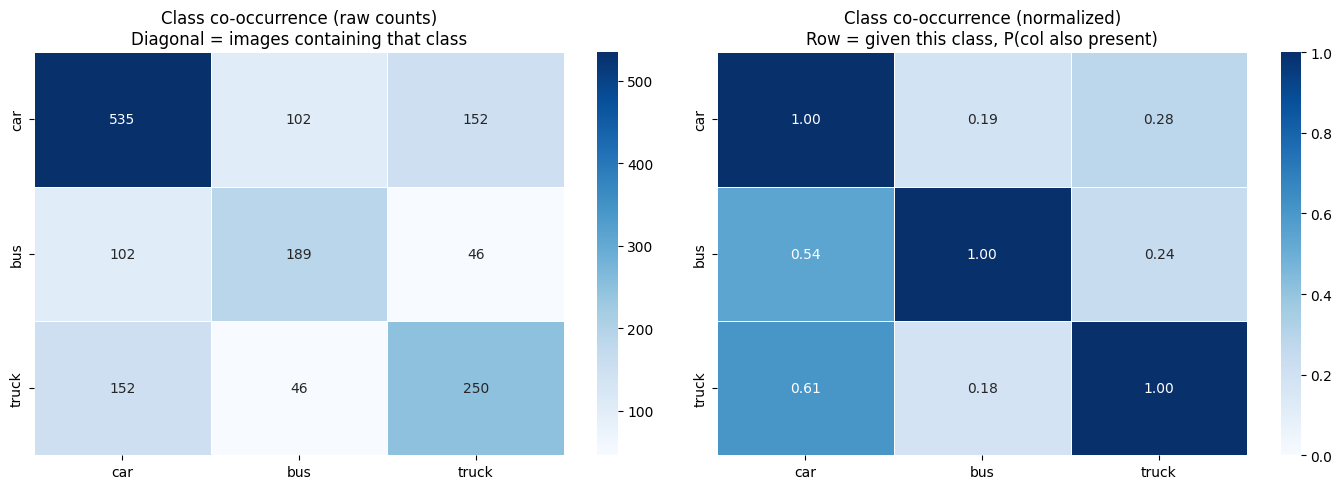

In [22]:
co_matrix = pd.DataFrame(0, index=VEHICLE_CLASSES, columns=VEHICLE_CLASSES)

for sample in dataset:
    if not sample.ground_truth:
        continue
    present = set(
        det.label for det in sample.ground_truth.detections
        if det.label in VEHICLE_CLASSES
    )
    for cls in present:
        co_matrix.loc[cls, cls] += 1
    for a, b in combinations(present, 2):
        co_matrix.loc[a, b] += 1
        co_matrix.loc[b, a] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[0], linewidths=0.5)
axes[0].set_title("Class co-occurrence (raw counts)\nDiagonal = images containing that class")

co_norm = co_matrix.astype(float).copy()
for cls in VEHICLE_CLASSES:
    total = co_matrix.loc[cls, cls]
    if total > 0:
        co_norm.loc[cls] = co_matrix.loc[cls] / total
    co_norm.loc[cls, cls] = 1.0

sns.heatmap(co_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
            linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title("Class co-occurrence (normalized)\nRow = given this class, P(col also present)")

plt.tight_layout()
plt.savefig(os.path.join(DATASET_DIR, "co_occurrence.png"), dpi=150, bbox_inches="tight")
plt.show()

## Image resolutions

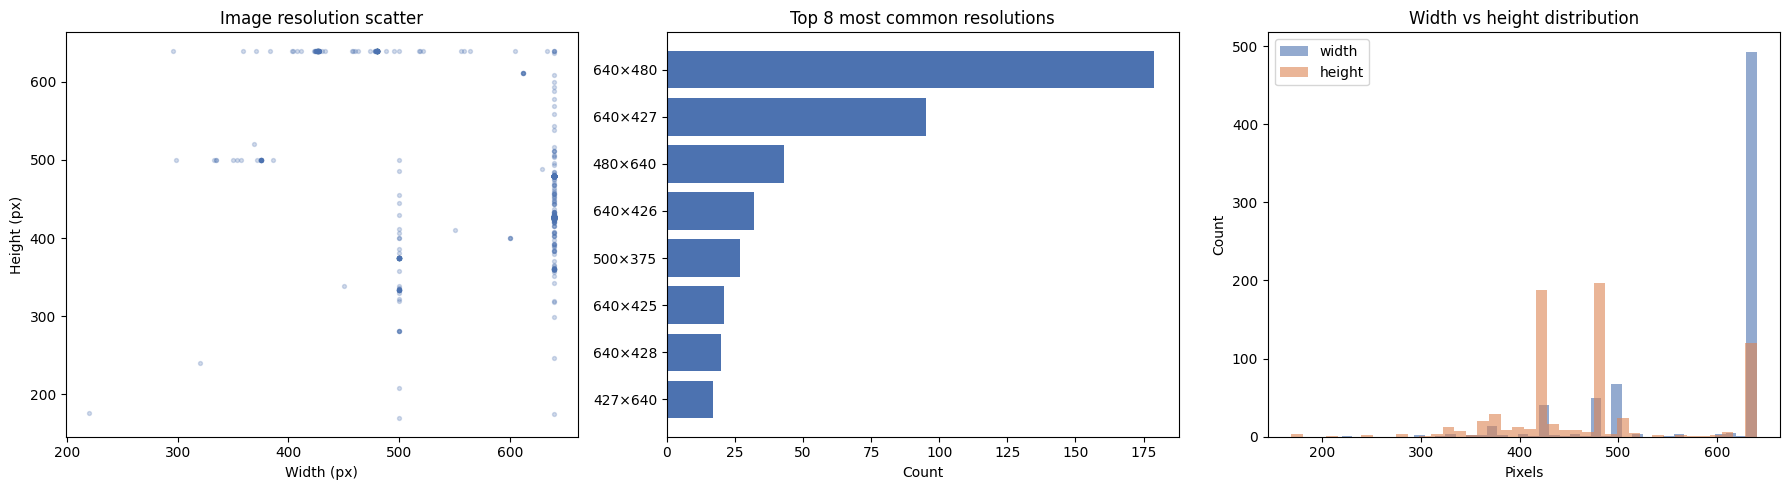

In [23]:
img_widths, img_heights = [], []

for sample in dataset:
    img = Image.open(sample.filepath)
    w, h = img.size
    img_widths.append(w)
    img_heights.append(h)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(img_widths, img_heights, alpha=0.25, s=8, color="#4C72B0")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title("Image resolution scatter")

top_res = Counter(zip(img_widths, img_heights)).most_common(8)
labels = [f"{w}×{h}" for (w, h), _ in top_res]
counts = [c for _, c in top_res]
axes[1].barh(labels[::-1], counts[::-1], color="#4C72B0")
axes[1].set_xlabel("Count")
axes[1].set_title("Top 8 most common resolutions")

axes[2].hist(img_widths, bins=40, alpha=0.6, color="#4C72B0", label="width")
axes[2].hist(img_heights, bins=40, alpha=0.6, color="#DD8452", label="height")
axes[2].set_xlabel("Pixels")
axes[2].set_ylabel("Count")
axes[2].set_title("Width vs height distribution")
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(DATASET_DIR, "image_resolutions.png"), dpi=150, bbox_inches="tight")
plt.show()